In [1]:
# --- Create price_history.csv (synthetic ~120 business days) ---
import numpy as np, pandas as pd

np.random.seed(23)

tickers = ["RELIANCE","HDFCBANK","INFY","TATAMOTORS","NIFTY50"]
start_prices = {"RELIANCE":2500.0,"HDFCBANK":1500.0,"INFY":1400.0,"TATAMOTORS":900.0,"NIFTY50":22000.0}

# 120 business days starting 2024-04-01
dates = pd.bdate_range("2024-04-01", periods=120)

# annualized drift/vol -> daily params
ann_mu    = np.array([0.14, 0.11, 0.12, 0.18, 0.10])
ann_sigma = np.array([0.22, 0.18, 0.20, 0.28, 0.15])
dt = 1/252
mu_d = (ann_mu - 0.5*ann_sigma**2)*dt
sigma_d = ann_sigma*np.sqrt(dt)

# weakly correlated shocks
corr = np.array([
    [1.00,0.65,0.55,0.50,0.70],
    [0.65,1.00,0.50,0.45,0.65],
    [0.55,0.50,1.00,0.40,0.60],
    [0.50,0.45,0.40,1.00,0.55],
    [0.70,0.65,0.60,0.55,1.00],
])
L = np.linalg.cholesky(corr)
Z = np.random.normal(size=(len(dates), len(tickers)))
eps = Z @ L.T

prices = pd.DataFrame(index=dates)
for i, t in enumerate(tickers):
    r = np.exp(mu_d[i] + sigma_d[i]*eps[:, i])      # GBM daily gross returns
    series = [start_prices[t]]
    for g in r: series.append(series[-1]*g)
    prices[t] = series[1:]

prices.index.name = "date"
prices = prices.round(2)
prices.to_csv("price_history.csv")
print("✅ Saved price_history.csv with shape:", prices.shape)
print(prices.head(), "\n...\n", prices.tail())

✅ Saved price_history.csv with shape: (120, 5)
            RELIANCE  HDFCBANK     INFY  TATAMOTORS   NIFTY50
date                                                         
2024-04-01   2524.38   1508.29  1395.95      917.29  22194.81
2024-04-02   2489.01   1492.47  1369.11      888.63  22163.67
2024-04-03   2478.20   1497.83  1373.05      889.51  22038.62
2024-04-04   2444.87   1492.95  1381.34      861.43  21791.44
2024-04-05   2439.17   1504.78  1391.02      874.43  21905.37 
...
             RELIANCE  HDFCBANK     INFY  TATAMOTORS   NIFTY50
date                                                         
2024-09-09   2483.88   1349.42  1241.49      853.44  19223.56
2024-09-10   2488.51   1359.34  1263.88      865.10  19202.22
2024-09-11   2505.75   1361.18  1259.03      879.37  19230.59
2024-09-12   2503.05   1368.86  1265.79      887.90  19306.06
2024-09-13   2482.34   1355.90  1256.35      880.70  19291.04


In [2]:
import sqlite3, pandas as pd, numpy as np, matplotlib.pyplot as plt

df = pd.read_csv("price_history.csv", parse_dates=["date"]).set_index("date").sort_index()
df.head()

,RELIANCE,HDFCBANK,INFY,TATAMOTORS,NIFTY50
date,,,,,
2024-04-01,2524.38,1508.29,1395.95,917.29,22194.81
2024-04-02,2489.01,1492.47,1369.11,888.63,22163.67
2024-04-03,2478.20,1497.83,1373.05,889.51,22038.62
2024-04-04,2444.87,1492.95,1381.34,861.43,21791.44
2024-04-05,2439.17,1504.78,1391.02,874.43,21905.37


In [3]:
conn = sqlite3.connect(":memory:")
df.reset_index().to_sql("prices", conn, index=False, if_exists="replace")

pd.read_sql_query("""
SELECT date, RELIANCE, HDFCBANK, INFY, TATAMOTORS, NIFTY50
FROM prices
ORDER BY date DESC
LIMIT 5
""", conn, parse_dates=["date"])

,date,RELIANCE,HDFCBANK,INFY,TATAMOTORS,NIFTY50
0,2024-09-13,2482.34,1355.90,1256.35,880.70,19291.04
1,2024-09-12,2503.05,1368.86,1265.79,887.90,19306.06
2,2024-09-11,2505.75,1361.18,1259.03,879.37,19230.59
3,2024-09-10,2488.51,1359.34,1263.88,865.10,19202.22
4,2024-09-09,2483.88,1349.42,1241.49,853.44,19223.56


In [4]:
rets = df.pct_change().dropna()
rets.head()

,RELIANCE,HDFCBANK,INFY,TATAMOTORS,NIFTY50
date,,,,,
2024-04-02,-0.014011,-0.010489,-0.019227,-0.031244,-0.001403
2024-04-03,-0.004343,0.003591,0.002878,0.000990,-0.005642
2024-04-04,-0.013449,-0.003258,0.006038,-0.031568,-0.011216
2024-04-05,-0.002331,0.007924,0.007008,0.015091,0.005228
2024-04-08,-0.012660,-0.007789,0.006492,-0.003065,-0.010601


In [5]:
trading_days = 252
mean_daily = rets[["RELIANCE","HDFCBANK","INFY","TATAMOTORS"]].mean()
vol_daily  = rets[["RELIANCE","HDFCBANK","INFY","TATAMOTORS"]].std()

ann_ret = (1 + mean_daily)**trading_days - 1
ann_vol = vol_daily * np.sqrt(trading_days)
sharpe  = ann_ret / ann_vol

metrics = pd.DataFrame({
    "Annual Return": ann_ret,
    "Annual Volatility": ann_vol,
    "Sharpe (rf=0)": sharpe
}).round(4).sort_values("Sharpe (rf=0)", ascending=False)

metrics

,Annual Return,Annual Volatility,Sharpe (rf=0)
RELIANCE,-0.0165,0.1954,-0.0844
TATAMOTORS,-0.0496,0.2670,-0.1856
INFY,-0.1851,0.1926,-0.9611
HDFCBANK,-0.1894,0.1775,-1.0666


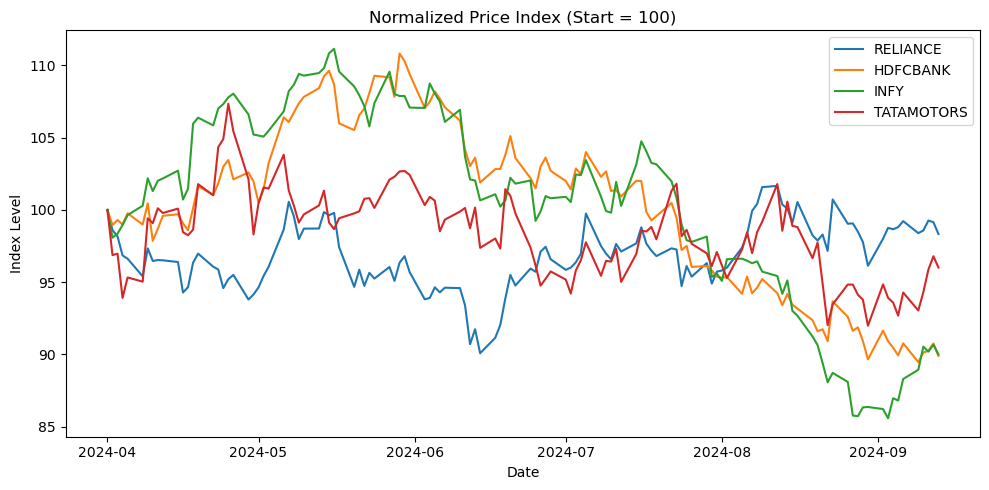

In [6]:
norm = df[["RELIANCE","HDFCBANK","INFY","TATAMOTORS"]] / df[["RELIANCE","HDFCBANK","INFY","TATAMOTORS"]].iloc[0] * 100
plt.figure(figsize=(10,5))
for col in norm.columns:
    plt.plot(norm.index, norm[col], label=col)
plt.title("Normalized Price Index (Start = 100)")
plt.xlabel("Date"); plt.ylabel("Index Level")
plt.legend()
plt.tight_layout()
plt.show()

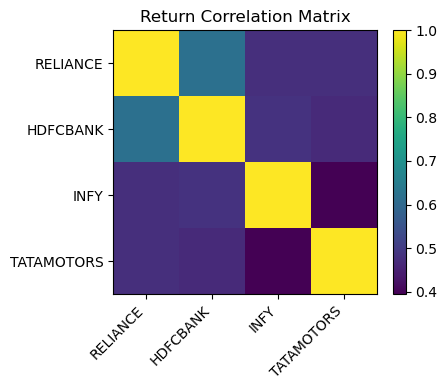

,RELIANCE,HDFCBANK,INFY,TATAMOTORS
RELIANCE,1.000000,0.617185,0.475277,0.475954
HDFCBANK,0.617185,1.000000,0.482365,0.467064
INFY,0.475277,0.482365,1.000000,0.394368
TATAMOTORS,0.475954,0.467064,0.394368,1.000000


In [7]:
corr = rets[["RELIANCE","HDFCBANK","INFY","TATAMOTORS"]].corr()
plt.figure(figsize=(5,4))
im = plt.imshow(corr.values, interpolation="nearest")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Return Correlation Matrix")
plt.tight_layout()
plt.show()
corr

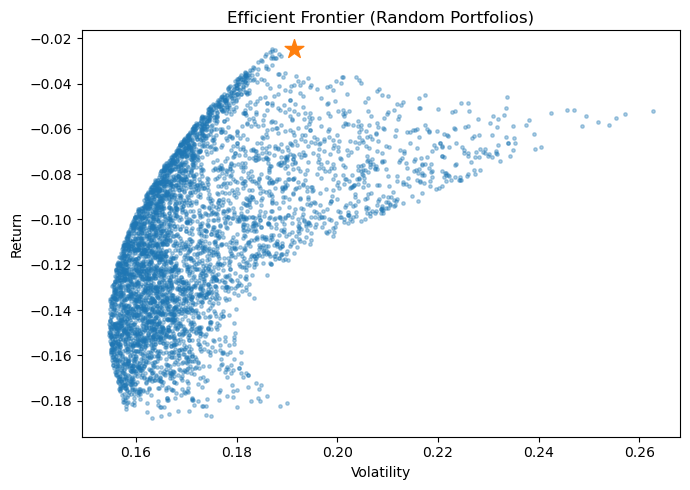

(   RELIANCE  HDFCBANK    INFY  TATAMOTORS
 0    0.9523    0.0463  0.0007      0.0007,
                   Metric     Value
 0      Max Sharpe Return -0.024642
 1  Max Sharpe Volatility  0.191383
 2       Max Sharpe Ratio -0.128759)

In [8]:
cov = rets[["RELIANCE","HDFCBANK","INFY","TATAMOTORS"]].cov() * trading_days
mu  = ann_ret.values

n_ports = 5000
weights = np.random.dirichlet(np.ones(4), size=n_ports)

port_ret = weights @ mu
port_vol = np.sqrt(np.einsum('ij,jk,ik->i', weights, cov.values, weights))
port_sharpe = port_ret / port_vol

idx_max = np.argmax(port_sharpe)
w_max = weights[idx_max]
ret_max, vol_max, sharpe_max = port_ret[idx_max], port_vol[idx_max], port_sharpe[idx_max]

plt.figure(figsize=(7,5))
plt.scatter(port_vol, port_ret, s=6, alpha=0.35)
plt.scatter(vol_max, ret_max, marker="*", s=200)
plt.xlabel("Volatility"); plt.ylabel("Return")
plt.title("Efficient Frontier (Random Portfolios)")
plt.tight_layout()
plt.show()

pd.DataFrame([w_max], columns=["RELIANCE","HDFCBANK","INFY","TATAMOTORS"]).round(4), \
pd.DataFrame({"Metric":["Max Sharpe Return","Max Sharpe Volatility","Max Sharpe Ratio"],
              "Value":[ret_max, vol_max, sharpe_max]})

In [9]:
metrics.to_csv("asset_metrics.csv")
import json
summary = {
    "max_sharpe_weights": dict(zip(["RELIANCE","HDFCBANK","INFY","TATAMOTORS"], w_max.round(4))),
    "max_sharpe": {"return": float(ret_max), "vol": float(vol_max), "sharpe": float(sharpe_max)}
}
with open("portfolio_summary.json","w") as f:
    json.dump(summary, f, indent=2)
print("✅ Exports saved: asset_metrics.csv, portfolio_summary.json")

✅ Exports saved: asset_metrics.csv, portfolio_summary.json
